<div style="border-bottom: 4px solid #003366; margin-bottom: 20px; padding-bottom: 10px; display: flex; justify-content: space-between; align-items: center;">
    <div style="flex-grow: 1;">
        <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-bottom: 5px;">MAT2605: Cálculo Científico I</h1>
        <h2 style="color: #555; margin-top: 0; margin-bottom: 10px;">Laboratorio 08: Cuadrados m&iacute;nimos</h2>
        <p style="margin: 2px 0;"><b>Profesores:</b> Thomas F&uuml;hrer y Manuel A. Sánchez | <b>Fecha:</b> 12 de junio, 2026</p>
        <p style="margin: 2px 0;"><b>Institución:</b> Facultad de Matemáticas, Pontificia Universidad Católica de Chile</p>
    </div>
    <div style="flex: 0 0 auto; margin-left: 20px;">
        <img src="../source/FacMatematicas-15.png" 
             alt="Logo UC" 
             style="height: 60px; width: auto;">
    </div>

</div>

<div style="border: 1px solid #2980b9; border-left: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">🎯 Objetivos de la Sesión</h3>
    <ul>
        <li>Regresi&oacute;n lineal</li>
        <li>Aproximaci&oacute;n polinomial mediante cuadrados m&iacute;nimos</li>
        <li>Polinomios ortogonales</li>
    </ul>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2e7d32; margin-top: 0;">👤 Identificación del Estudiante</h3>
    <p style="margin-bottom: 10px; color: #555;">Por favor, completa tus datos antes de comenzar:</p>
    <ul style="list-style-type: none; padding-left: 0; color: #333;">
        <li style="margin-bottom: 5px;"><b>📌 Nombre Completo:</b> _______________________________________</li>
        <li style="margin-bottom: 5px;"><b>📌 Rol / Nº Alumno:</b> _________________________</li>
    </ul>
    <p style="font-size: 0.85em; color: #2e7d32; margin-top: 15px; border-top: 1px solid #a5d6a7; padding-top: 5px;">
        <i>💡 Haz doble clic en esta celda para editarla con tus datos.</i>
    </p>
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import math

# INTENTO DE CONFIGURACIÓN DE ESTILO (Compatible con versiones viejas y nuevas)
try:
    plt.style.use('seaborn-v0_8-whitegrid') # Nombre nuevo (Matplotlib 3.6+)
except OSError:
    plt.style.use('seaborn-whitegrid')      # Nombre antiguo

plt.rcParams['figure.figsize'] = (10, 6)

print(f"Versión de Numpy: {np.__version__}")
print(f"Estilo usado: {plt.style.context}")

Versión de Numpy: 2.4.6
Estilo usado: <function context at 0x7f1201276820>


<div class="alert-block alert-warning "; style=" border-left: 5px solid #ffc107; padding: 15px; border-radius: 5px;">
    <h3 style="color: #d35400; margin-top: 0;">📚 Teoría:</h3>
    Se discuta en cada secci&oacute;n.
</div>

# Regresi&oacute;n

El siguiente programa determina los coeficientes del polinomio $p\in\mathcal{P}_n$ que minimiza
$$\sum_{j=0}^m w_j(y_j-p(x_j))^2$$
es decir, minimiza la distancia cuadr&aacute;tica con pesos $w_0,...,w_m$. Eso es equivalente a resolver el sistema de ecuaciones normales, 
$$ A^\top D A c= A^\top D y$$
donde $A$ es la matriz Vandermonde en los nodos $x_0,...,x_m$, $y = (y_0,...,y_m)$ y $D$ es la matriz diagonal con coeficientes $w_0,...,w_m$.

In [2]:
def cuad_min(x, y, n, w=None):
    x = np.asarray(x).flatten()
    y = np.asarray(y).reshape(-1, 1)
    
    if w is not None:
        w = np.asarray(w).flatten()
    else:
        w = np.ones(len(x))
        
    D = np.diag(w)               # matriz diagonal
    A = np.vander(x)[:, -(n+1):] # generar matriz vandermonde
    
    M = A.T @ D @ A
    b = A.T @ D @ y
    
    coeff = np.linalg.solve(M, b)
    return coeff.flatten()

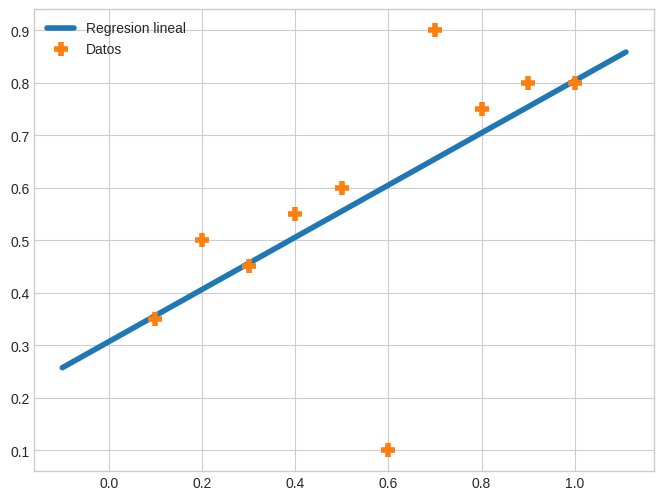

In [3]:
# Ejemplo
x = np.arange(0.1, 1.1, 0.1) 
y = np.array([0.35, 0.5, 0.45, 0.55, 0.6, 0.1, 0.9, 0.75, 0.8, 0.8])

# Coeficientes del polinomio
coeff = cuad_min(x, y, 1)

# graficamos la solucion en estos puntos
xq = np.linspace(-0.1, 1.11, 101)
# usar polyval para evaluar el polinomio con coeficientes guardado en coeff
yq = np.polyval(coeff, xq)

# Graficar
plt.figure(figsize=(8, 6))
plt.plot(xq, yq, label='Regresion lineal', linewidth=4)
plt.plot(x, y, '+', label='Datos', markersize=10, markeredgewidth=4)

plt.grid(True)
plt.legend()
plt.show()

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio (sin evaluaci&oacute;n):</h3>
    Determina y grafica el polinomio $p\in \mathcal{P}_2$ que minimiza la distancia euclideana (usando los mismos datos $(x_j,y_j)$ del ejemplo anterior).
</div>

In [ ]:
# Tu codigo va aqui


<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio (sin evaluaci&oacute;n):</h3>
    Dados los datos $(x_0,y_0) = (0,1)$, $(x_1,y_1) = (0.5,3)$, $(x_2,y_2) = (1,0)$, considere la regresi&oacute;n lineal con pesos. Explique el efecto de la selecci&oacute;n de los pesos. Considera al menos: 
    <ul>
        <li>$w = (0,1,2)$ (por que funciona el codigo con un peso igual a $0$? Cual es la conexion con interpolacion polinomial?)</li>
        <li>$w = (1000,1,1000)$</li>
        <li>$w = (1,1000,1)$</li>
        <li>$w = (0.001,1,0.01)$</li>
    </ul>
</div>

In [10]:
# tu codigo



# Polinomios de Legendre

Se determinan con la recursi&oacute;n
$$ L_{n+1}(x) = \frac{2n+1}{n+1}xL_n(x) - \frac{n}{n+1}L_{n-1}(x), \quad n=1,2,\ldots$$
con $L_0(x) = 1$ y $L_1(x) = x$. 

Ademas, 
$$ L_n(1) = 1, \quad \langle L_n,L_n\rangle = \int_{-1}^1 L_n(x)L_n(x)\,\mathrm{d}x = \frac{2}{2n+1}, \quad n\geq 0.$$

Nota que $\langle L_j,L_k\rangle = 0$ para $j\neq k$.

In [126]:
N = 10 # Crear hasta L_N
# Los primeros 2 polinomios de Legendre (L_0(x) = 1, L_1(x) = x
L = [
    lambda x: np.ones_like(x, dtype=float),  # L_0(x) = 1
    lambda x: np.asarray(x, dtype=float)    # L_1(x) = x
]

def make_legendre(n, L_n, L_nm1):
    return lambda x: ((2.0 * n + 1.0) / (n + 1.0)) * x * L_n(x) - (n / (n + 1.0)) * L_nm1(x)

for n in range(2, N+1):
    L.append(make_legendre(n-1, L[n-1], L[n-2]))

Seg&uacute;n lo visto en clase tenemos que
$$ p = \sum_{j=0}^n \frac{\langle f,L_j\rangle}{\langle L_j,L_j\rangle} L_j$$ es el polinomio del grado $\leq n$ que satisface
$$
\|p-f\| = \min_{q\in \mathcal{P}_n} \|q-f\|
$$
donde $\|g\| := \sqrt{\langle g,g\rangle} = \sqrt{\int_{-1}^1 g(x)^2\,\mathrm{d}x}$.

Para los ejemplos tenemos que integrar funciones. Num&eacute;ricamente, se aproxima mediante una cuadratura,
$$
\int_{-1}^1 f(x) \,\mathrm{d}x \approx \sum_{j=0}^n f(x_j) w_j
$$
donde $w_0,\ldots,w_n$ son los pesos de la cuadratura, y $x_0,\ldots,x_n$ son los nodos de la cuadratura. 
Veremos mas detalles en el capitulo sobre integraci&oacute;n num&eacute;rica. Por el momento usaremos es siguiente algoritmo para generar los nodos y los pesos.  

In [121]:
# Este codigo genera nodos y pesos para la cuadratura
def golub_welsch(n):
    # Create the indices from 1 to n-1
    i = np.arange(1, n)
    
    # Compute the sub-diagonal elements for the Legendre polynomial relation
    beta = i / np.sqrt(4 * i**2 - 1)
    
    # Construct the symmetric tridiagonal Jacobi matrix
    jacobi_matrix = np.diag(beta, k=1) + np.diag(beta, k=-1)
    
    # Compute eigenvalues (nodes) and eigenvectors
    nodes, eigenvectors = np.linalg.eigh(jacobi_matrix)
    
    # Weights are calculated from the first row of the normalized eigenvectors
    weights = 2 * (eigenvectors[0, :] ** 2)
    
    return nodes, weights

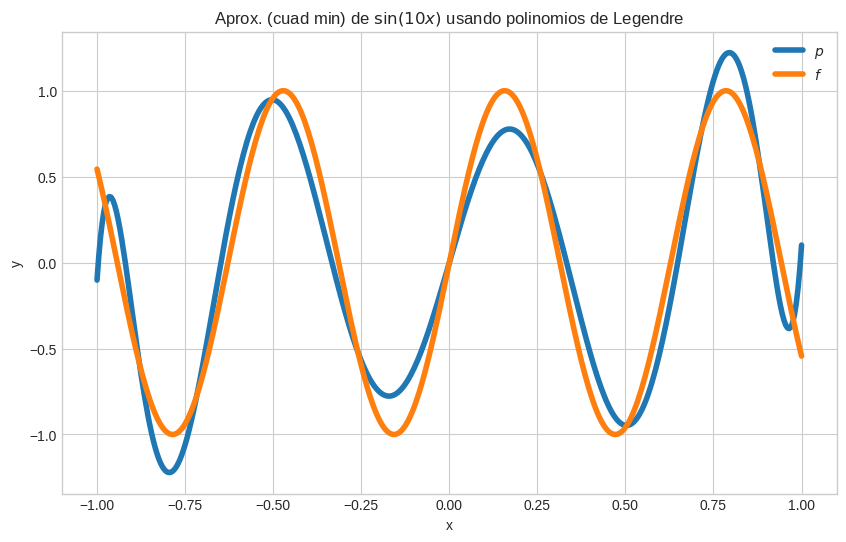

In [129]:
# Ejemplo
f = lambda x: np.sin(10*x)

# Determinar coeficientes c_j = <f,L_j>
quad_nodos, quad_pesos = golub_welsch(16)
c = np.zeros(len(L))
for j in range(len(L)):
    c[j] = np.dot(f(quad_nodos)*L[j](quad_nodos),quad_pesos)

# puntos en que queremos evaluar
xq = np.linspace(-1,1,401)

# Evaluar polinomio p
p = np.zeros(len(xq))
for j in range(len(L)):
    p = p + c[j]*(2*j+1.0)/2.0*L[j](xq)

## Graficar
plt.figure(figsize=(10, 6))
plt.plot(xq, p, label='$p$', linewidth=4)
plt.plot(xq, f(xq), label='$f$', linewidth=4)

plt.grid(True)
plt.title("Aprox. (cuad min) de $\\sin(10x)$ usando polinomios de Legendre")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio (sin evaluaci&oacute;n):</h3>
    Compara el &uacute;ltimo ejemplo con interpolaci&oacute;n polinomial (grado $\leq N$):
    <ul>
        <li>Distribuci&oacute;n uniforme de los nodos de interpolaci&oacute;n</li>
        <li>Usando los nodos de Chebychev</li>
    </ul>
    Aumenta el grado polinomial. Que se observa?
</div>

---
<div class="alert alert-block alert-success"> 

## Evaluaci&oacute;n:

</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio 1:</h3>
    Se anuncia durante el Laboratorio.
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

In [18]:
# Espacio para tu codigo:


<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio 2:</h3>
Se anuncia durante el Laboratorio.
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

In [19]:
# Espacio para tu codigo:



<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio 3: </h3>
    Se anuncia durante el Laboratorio.
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

In [20]:
# Espacio para tu codigo:


